# CIL-level L2 Cache Behavior

In [1]:
from analyzer_functions import *

## Non-persistent L2 cache

In [2]:
#l1_path = 'data/l2/nonpersist/ada-l2NP-l1-100k.csv'
l1_path = 'data/l2Store/1080-l1wb-100k.csv'
#l2_path = 'data/l2/nonpersist/ada-l2NP-l2-100k.csv'
l2_path = 'data/l2Store/1080-l2cg-100k.csv'
# spin_path = 'data/ada-spin-100k.csv'

l1_ivls = read_ivls(l1_path, single=True)
l2_ivls = read_ivls(l2_path, single=True)
# spin_ivls = read_ivls(spin_path, single=True)

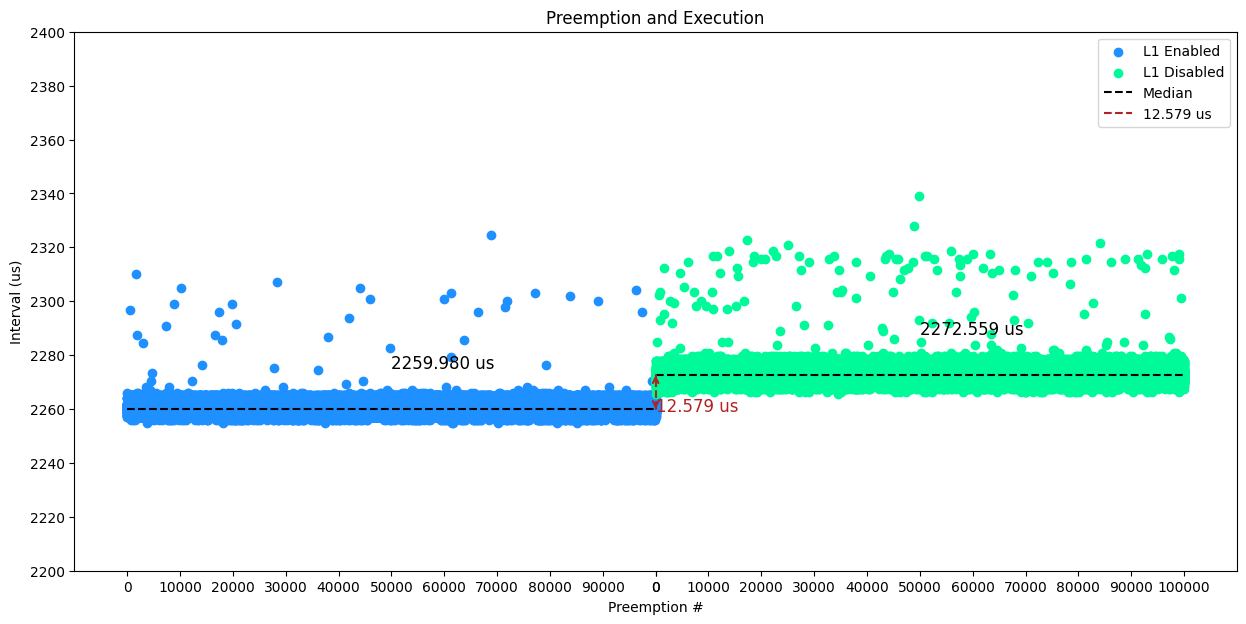

In [3]:
N = 100000
plot_side_by_side(noSharedData=l1_ivls, sharedData=l2_ivls, NUM_SAMPLES=N, lowerBound=2200, upperBound=2400,
 				  firstLabel='L1 Enabled', secondLabel='L1 Disabled', medianLines=True)

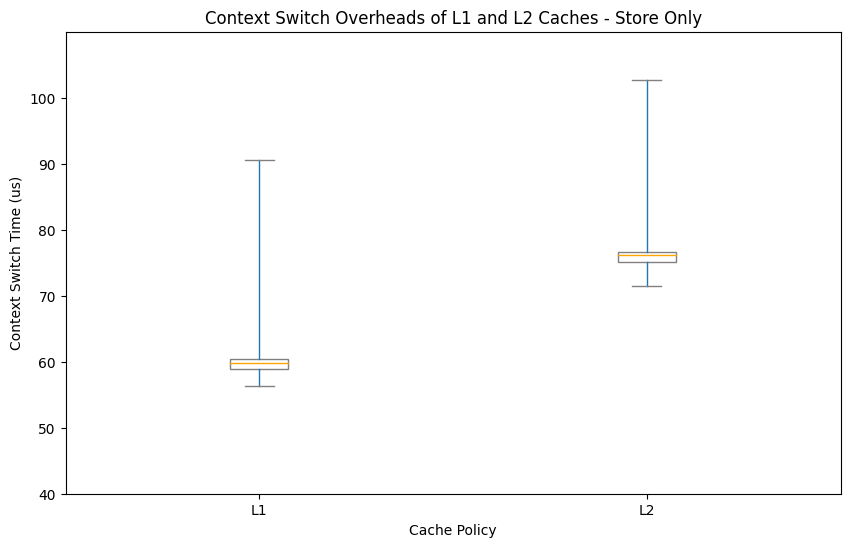

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Create a dataframe of NumPy arrays
l1_wb_ivls = read_ivls('data/l2Store2/1080-l1wb-100k.csv', single=True)
l1_wt_ivls = read_ivls('data/l2Store2/1080-l1wt-100k.csv', single=True)
l2_cg_ivls = read_ivls('data/l2Store2/1080-l2cg-100k.csv', single=True)
l2_wb_ivls = read_ivls('data/l2Store2/1080-l2wb-100k.csv', single=True)
l2_wt_ivls = read_ivls('data/l2Store2/1080-l2wt-100k.csv', single=True)
TIMESLICE_LENGTH = 2131
# l1_oh = get_overhead(l1_ivls, TIMESLICE_LENGTH)
# l2_oh = get_overhead(l2_ivls, TIMESLICE_LENGTH)
l1_wb = get_overhead(l1_wb_ivls, TIMESLICE_LENGTH)
l1_wt = get_overhead(l1_wt_ivls, TIMESLICE_LENGTH)
l2_cg = get_overhead(l2_cg_ivls, TIMESLICE_LENGTH)
l2_wb = get_overhead(l2_wb_ivls, TIMESLICE_LENGTH)
l2_wt = get_overhead(l2_wt_ivls, TIMESLICE_LENGTH)
data = {
	'L1': l1_wb,
	'L2': l2_cg
}

# Convert the list of NumPy arrays to a DataFrame
df = pd.DataFrame(data)

# Create a boxplot
def multi_boxplot(df, title, ymin=None, ymax=None, tick_step=1):
	plt.figure(figsize=(10, 6))
	df.boxplot(grid=False, 
           patch_artist=True,
           boxprops=dict(facecolor='none', color='gray'),
           flierprops=dict(markerfacecolor='red', marker='o', markersize=5),
           medianprops=dict(color='orange', linewidth=1),
		   capprops=dict(color='gray', linewidth=1),
		   whis=[0,100])
	plt.title(title)
	plt.xlabel('Cache Policy')
	plt.ylabel('Context Switch Time (us)')

	# y ticks
	if ymin is None:
		ymin = np.floor(df.min().min()) - 10
	if ymax is None:
		ymax = np.ceil(df.max().max()) + 10
	plt.ylim(ymin, ymax)
	plt.yticks(np.arange(ymin, ymax, tick_step))
	LABEL_STEP = 5
	plt.gca().set_yticks(np.arange(ymin, ymax, tick_step).tolist())
	plt.gca().set_yticklabels(np.arange(ymin, ymax, tick_step).tolist())
	# Show minor ticks (for tick marks every 1 unit)
	#plt.gca().tick_params(axis='y', which='both', length=8, width=tick_step)
	# Show minor ticks and adjust their appearance
	#plt.gca().tick_params(axis='y', which='minor', length=4, width=tick_step)
	# Add minor ticks at every unit
	#plt.gca().minorticks_on()
	# Disable minor ticks on the x-axis
	#plt.gca().tick_params(axis='x', which='minor', length=0)
	plt.show()
multi_boxplot(df, 'Context Switch Overheads of L1 and L2 Caches - Store Only', ymin=40, ymax=110, tick_step=10)

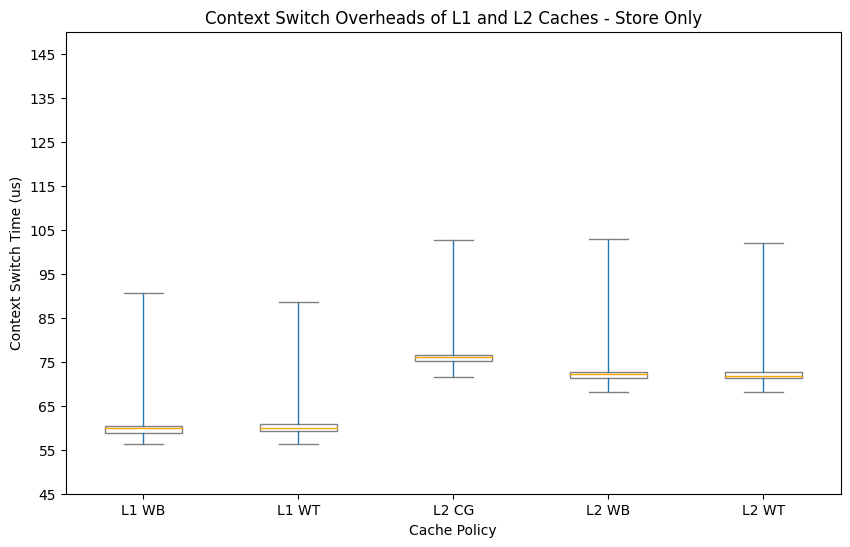

In [5]:
df = {
	'L1 WB': l1_wb,
	'L1 WT': l1_wt,
	'L2 CG': l2_cg,
	'L2 WB': l2_wb,
	'L2 WT': l2_wt
}
df = pd.DataFrame(df)
multi_boxplot(df, 'Context Switch Overheads of L1 and L2 Caches - Store Only', 45, 150, 10)

## Load and Store

Difference is that store only as = i while load and store has += i

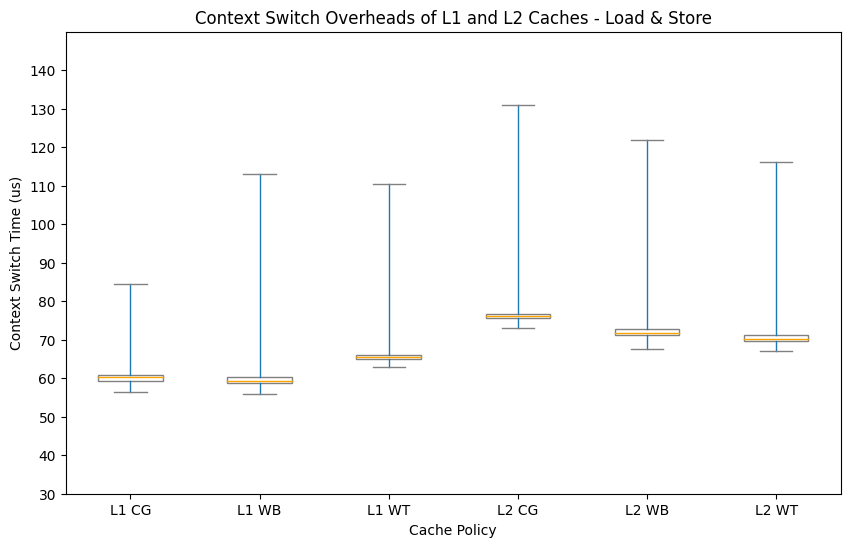

In [6]:
# Create a dataframe of NumPy arrays

def plot_dir(dir, title, lower=30, upper=150, tick_step=1):
	l1_cg_ivls = read_ivls('data/'+dir+'/1080-l1cg-100k.csv', single=True)
	l1_wb_ivls = read_ivls('data/'+dir+'/1080-l1wb-100k.csv', single=True)
	l1_wt_ivls = read_ivls('data/'+dir+'/1080-l1wt-100k.csv', single=True)
	l2_cg_ivls = read_ivls('data/'+dir+'/1080-l2cg-100k.csv', single=True)
	l2_wb_ivls = read_ivls('data/'+dir+'/1080-l2wb-100k.csv', single=True)
	l2_wt_ivls = read_ivls('data/'+dir+'/1080-l2wt-100k.csv', single=True)
	l1_cg = get_overhead(l1_cg_ivls, TIMESLICE_LENGTH)
	l1_wb = get_overhead(l1_wb_ivls, TIMESLICE_LENGTH)
	l1_wt = get_overhead(l1_wt_ivls, TIMESLICE_LENGTH)
	l2_cg = get_overhead(l2_cg_ivls, TIMESLICE_LENGTH)
	l2_wb = get_overhead(l2_wb_ivls, TIMESLICE_LENGTH)
	l2_wt = get_overhead(l2_wt_ivls, TIMESLICE_LENGTH)

	data = {
		'L1 CG': l1_cg,
		'L1 WB': l1_wb,
		'L1 WT': l1_wt,
		'L2 CG': l2_cg,
		'L2 WB': l2_wb,
		'L2 WT': l2_wt
	}

	# Convert the list of NumPy arrays to a DataFrame
	df = pd.DataFrame(data)

	multi_boxplot(df, 'Context Switch Overheads of L1 and L2 Caches - '+title, lower, upper, tick_step=tick_step)

plot_dir('l2LoadStore', 'Load & Store', lower=30, upper=150, tick_step=10)

## Fill and Spin

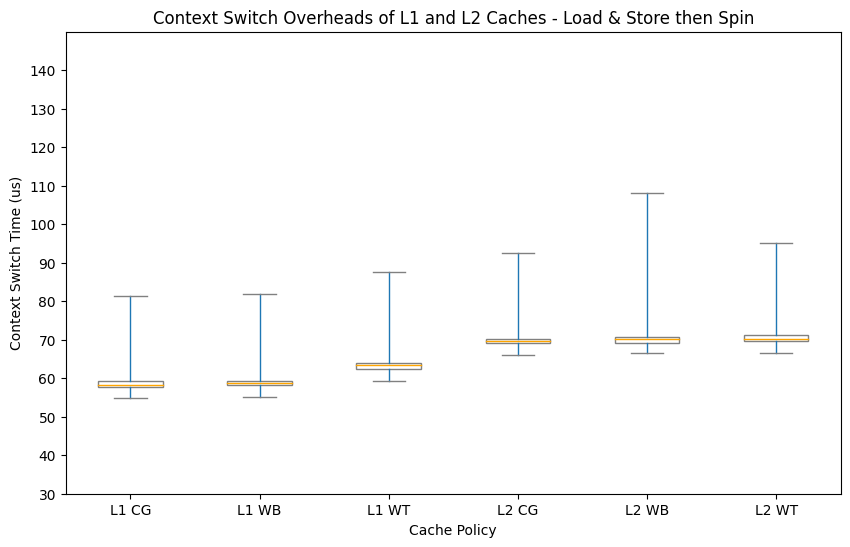

In [7]:
plot_dir('l2FillSpin', 'Load & Store then Spin', 30, 150, 10)

## Read and accumulate

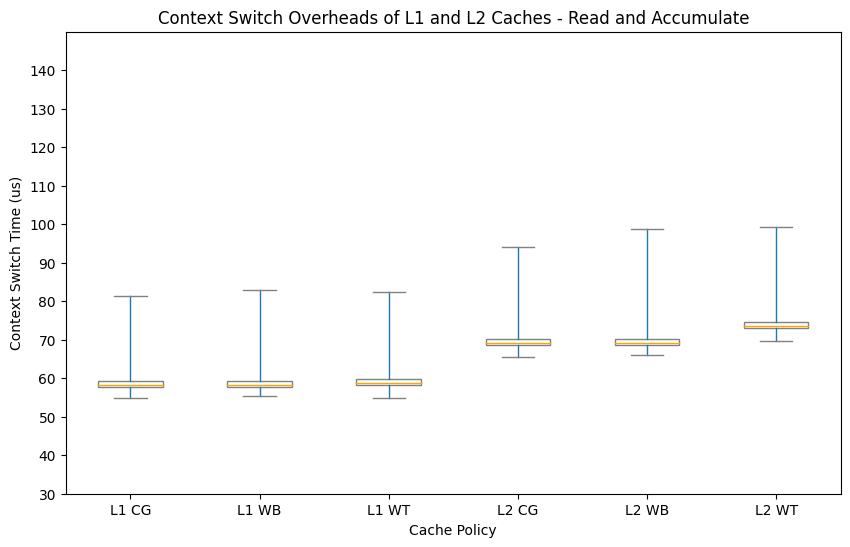

In [8]:
plot_dir('l2ReadAcc', 'Read and Accumulate', 30, 150, 10)

## Read and accumulate - host alloced

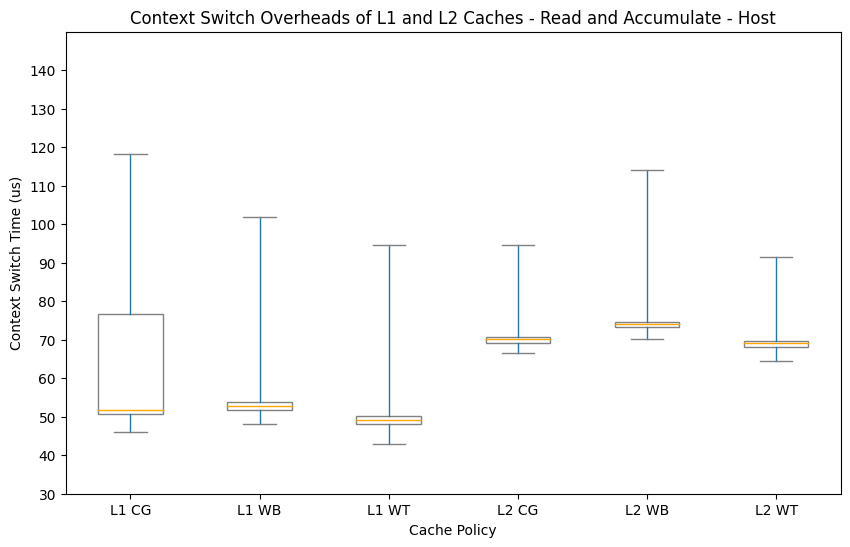

In [9]:
plot_dir('l2HostReadAcc', 'Read and Accumulate - Host', lower=30, upper=150, tick_step=10)

## Preempts probably during writes - Host

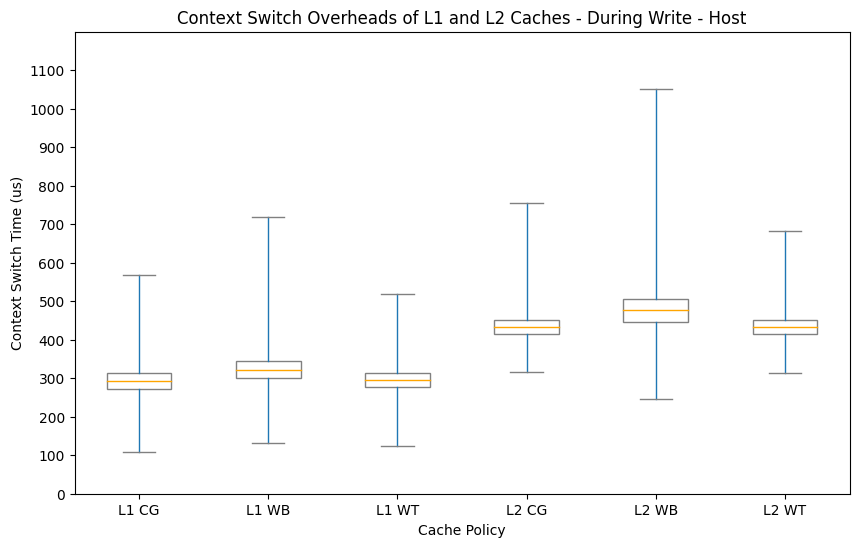

In [10]:
plot_dir('l2HostWriteSpin', 'During Write - Host', lower=0, upper=1200, tick_step=100)

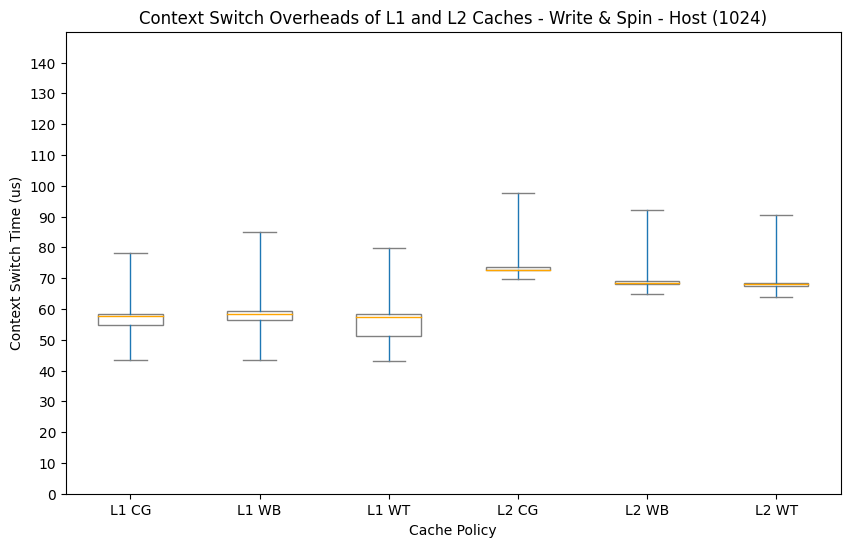

In [11]:
plot_dir('l2HostWriteSpin1024', 'Write & Spin - Host (1024)', lower=0, upper=150, tick_step=10)

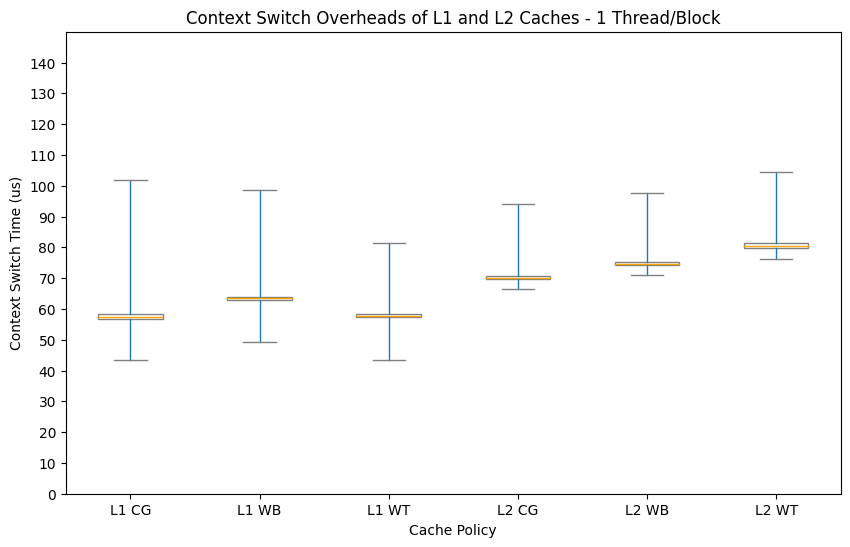

In [12]:
plot_dir('l2HostWriteSpin1024-1ThreadPerBlock', '1 Thread/Block', lower=0, upper=150, tick_step=10)

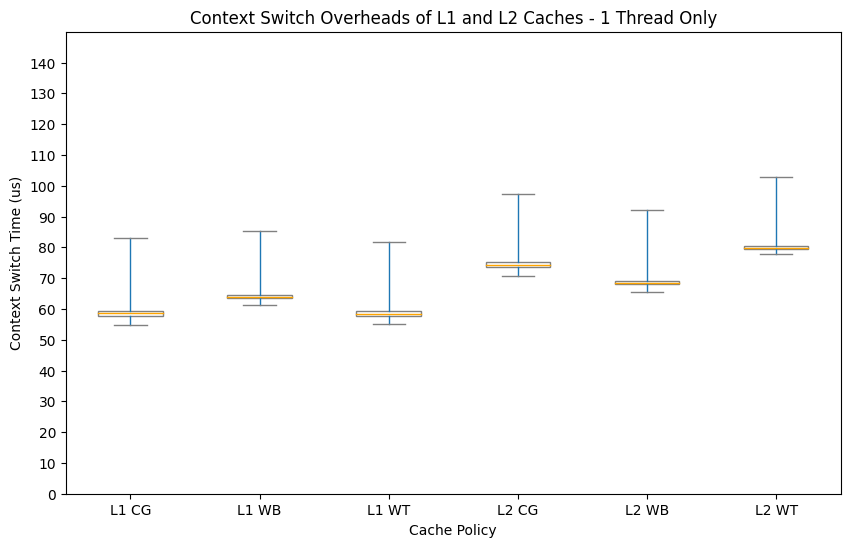

In [13]:
plot_dir('l2HostWriteSpin1024-1GlobalThread', '1 Thread Only', lower=0, upper=150, tick_step=10)

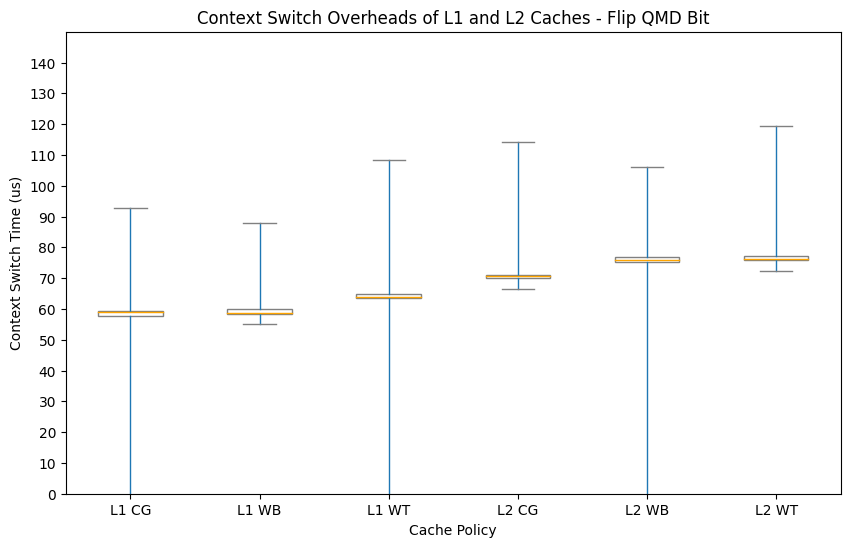

In [14]:
plot_dir('qmdBit', 'Flip QMD Bit', lower=0, upper=150, tick_step=10)

## Device Memory

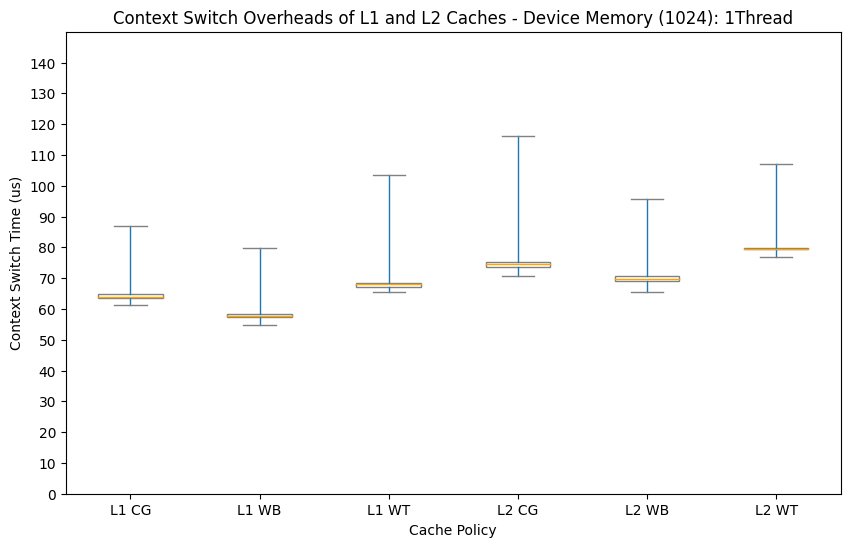

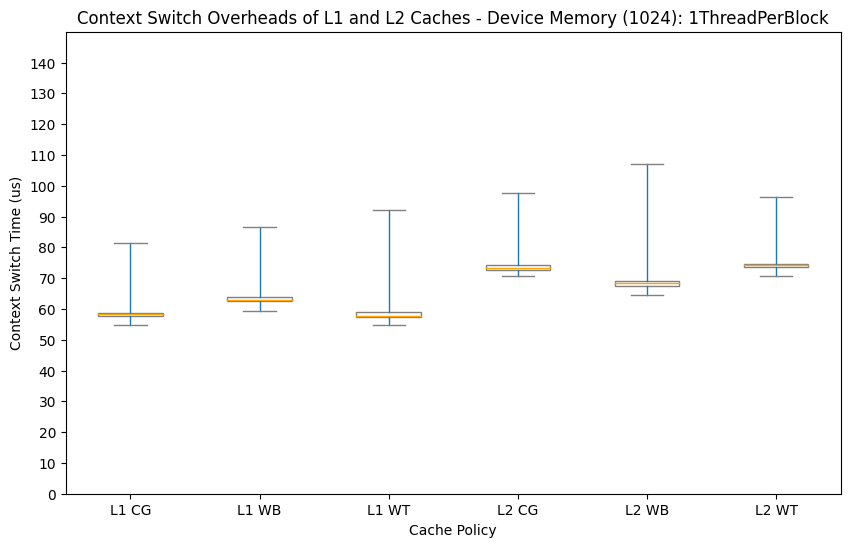

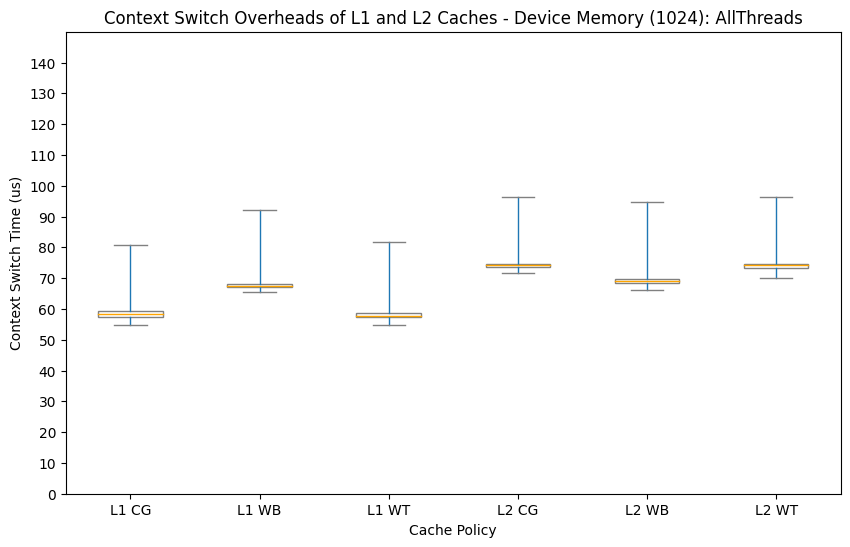

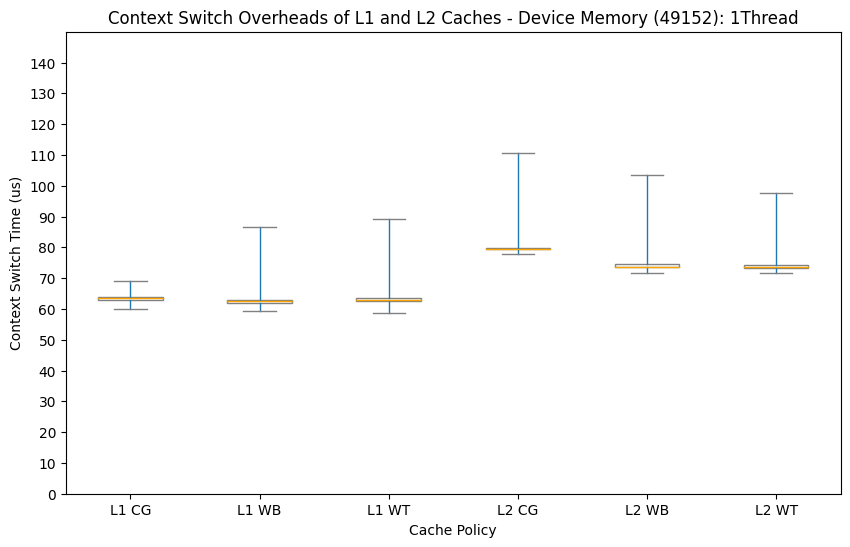

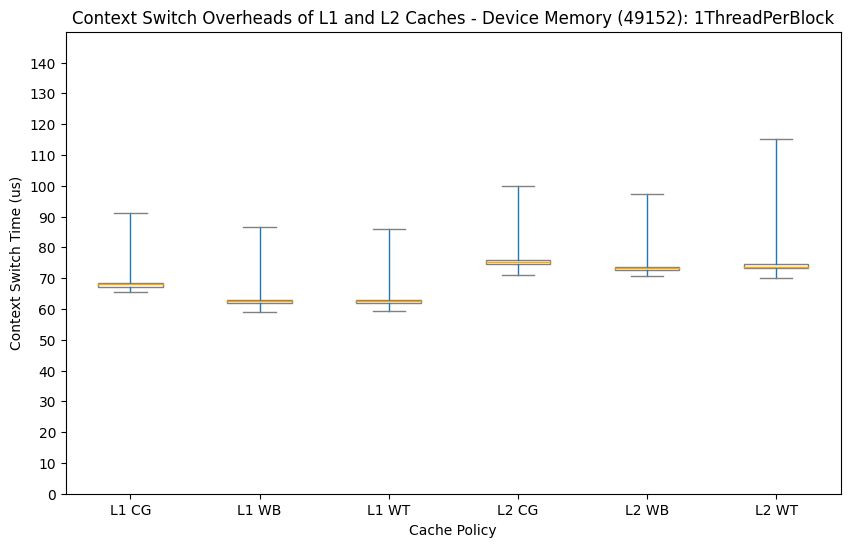

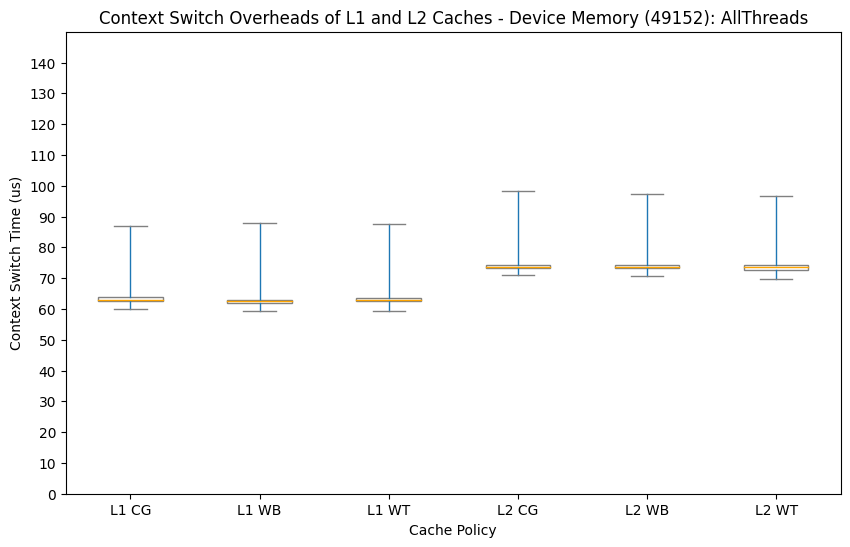

In [15]:
dirs = ['1Thread', '1ThreadPerBlock', 'AllThreads']
for d in dirs:
	plot_dir('deviceThread1024'+f'/{d}', f'Device Memory (1024): {d}', lower=0, upper=150, tick_step=10)
for d in dirs:
	plot_dir('deviceThread49152'+f'/{d}', f'Device Memory (49152): {d}', lower=0, upper=150, tick_step=10)

## Data Usage

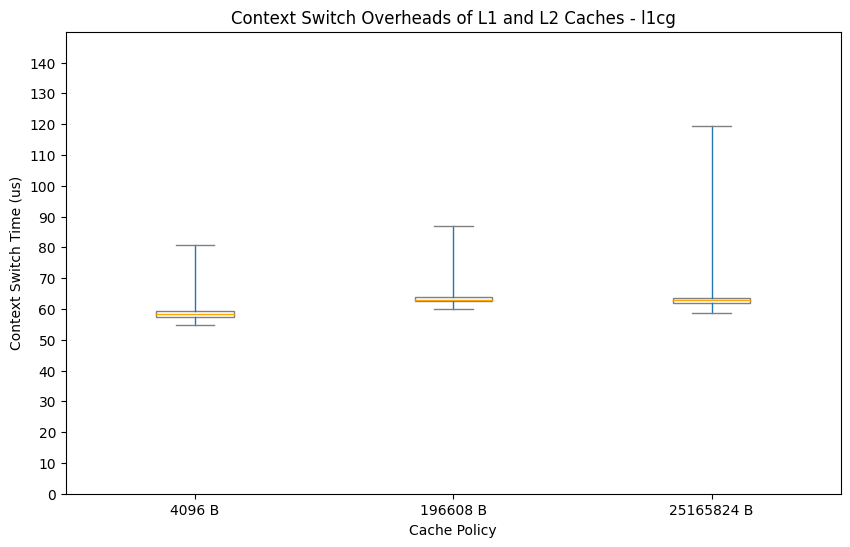

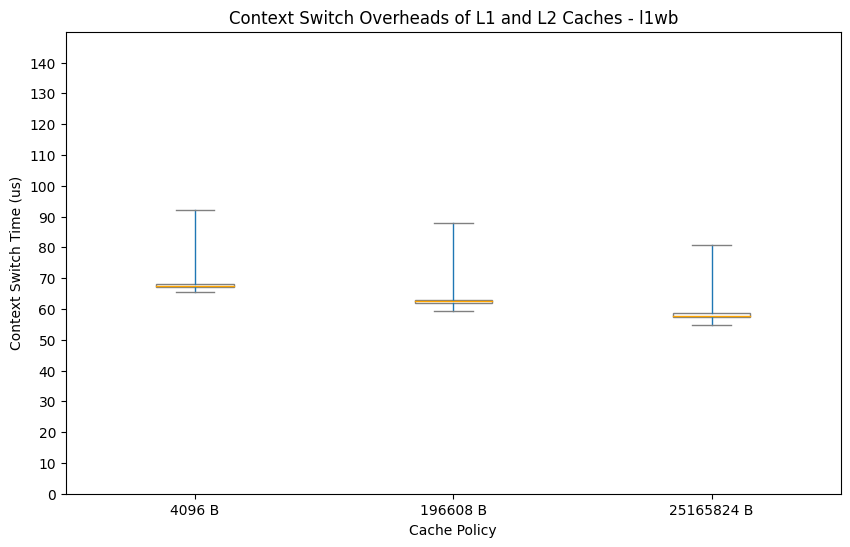

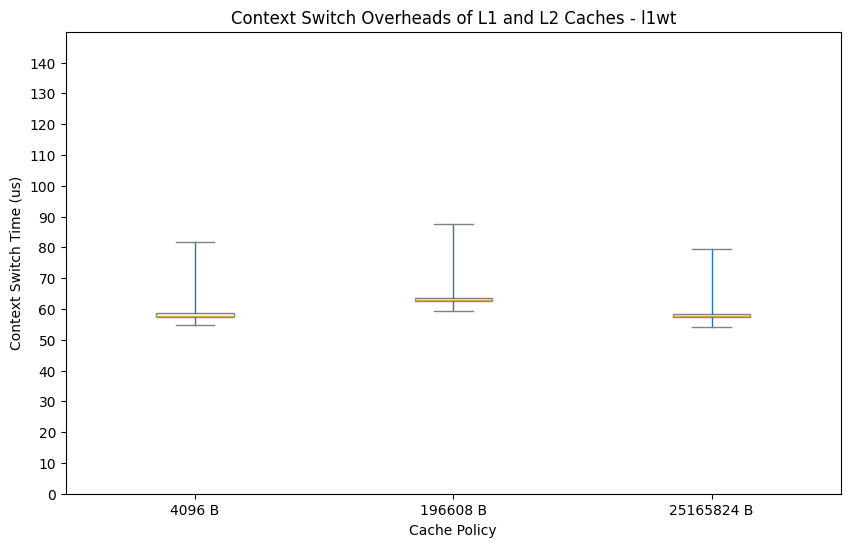

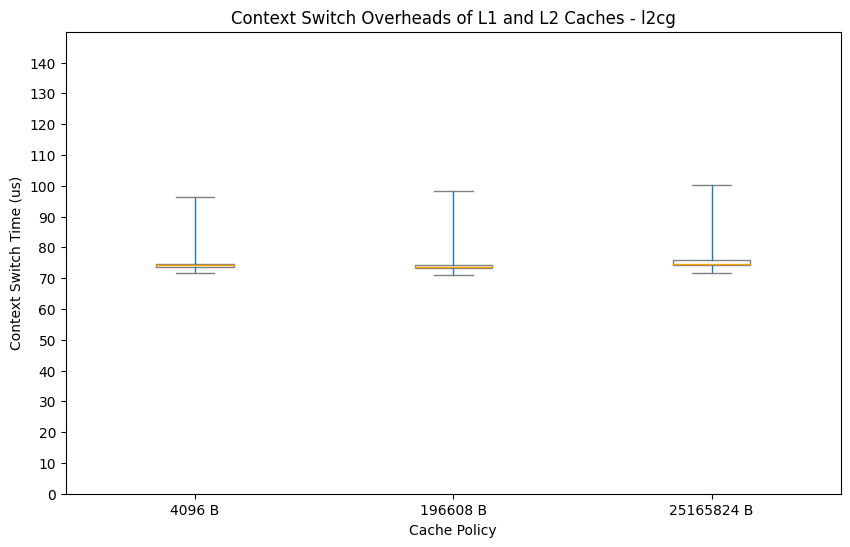

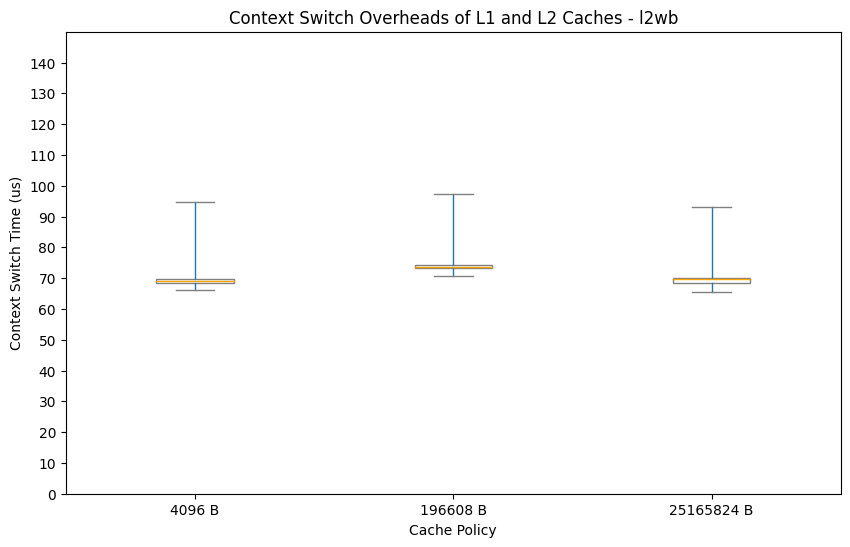

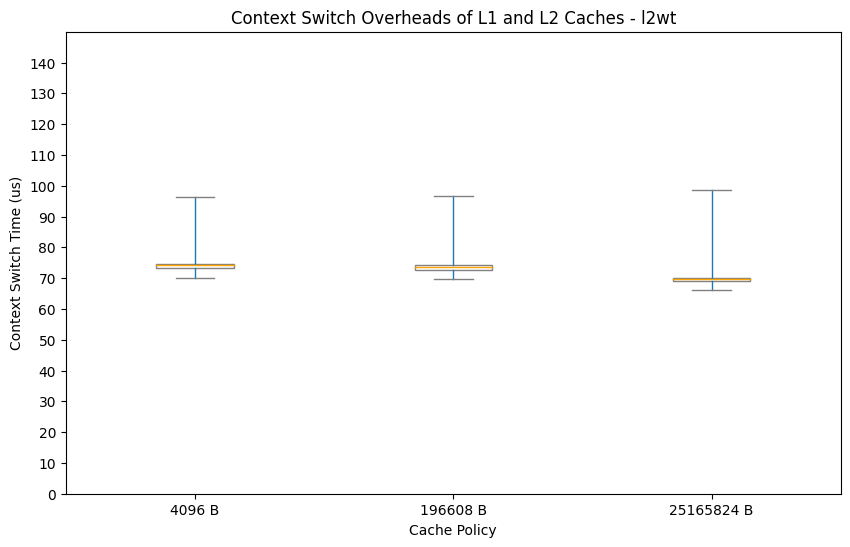

In [16]:
cache_configs = ['l1cg', 'l1wb', 'l1wt', 'l2cg', 'l2wb', 'l2wt']
arr_sizes = [1024, 49152, 6291456]
lower = 0
upper = 150
tick_step = 10
for config in cache_configs:
	data = {}
	for size in arr_sizes:
		file = 'data/deviceThread'+f'{size}'+'/AllThreads/'+f'1080-{config}-100k.csv'
		ivls = read_ivls(file, single=True, us=True)
		oh = get_overhead(ivls, TIMESLICE_LENGTH, convert2us=False)
		data[f'{size*4} B'] = oh
	df = pd.DataFrame(data)
	multi_boxplot(df, 'Context Switch Overheads of L1 and L2 Caches - '+f'{config}', lower, upper, tick_step=tick_step)	

## Spin, Fill then Spin, Preempt on LD/ST

In [17]:
ivls = read_ivls('data/spinFillMem/1080-native6291456-100k.csv', single=True, us=True)
oh = get_overhead(ivls, TIMESLICE_LENGTH, convert2us=False, double=False)

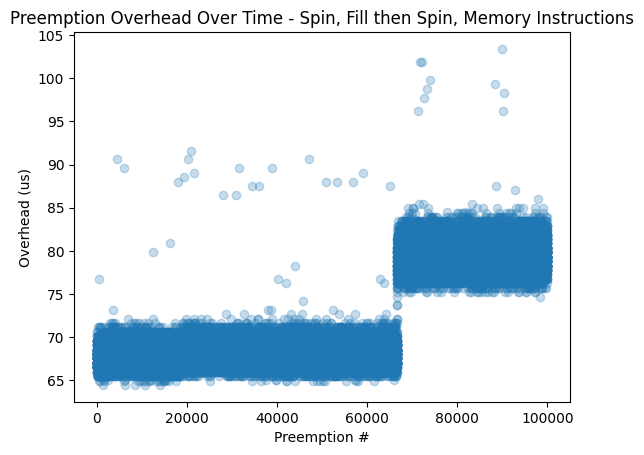

In [18]:
oh_over_time(oh, N, alpha=0.25, title='Preemption Overhead Over Time - Spin, Fill then Spin, Memory Instructions')